## General case

<!-- Open in Colab -->

<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/snn_general.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>





We have described several example shallow networks to help develop intuition about how
they work. We now define a general equation for a shallow neural network $$ \textbf{y = f}[\textbf{x},\mathbf{\phi}]$$

that maps a multi-dimensional input $\textbf{x} \in \mathcal{R^{D_i}}$ to a multi-dimensional output $\textbf{y} \in \,\mathcal{R}^{D_o}$ using D hidden units. Each hidden unit is computed as:

\begin{eqnarray}\label{eq:snn_general_1}
 h_{d} = \mbox{a}\left[\theta_{d0} + \sum_{i=1}^{D_{i}}\theta_{di}x_i\right], 
 \end{eqnarray}

and these are combined linearly to create the output:

\begin{eqnarray}\label{eq:snn_general_2}
 y_j = \phi_{j0}+\sum_{d=1}^{D}\phi_{jd}h_{d},
 \end{eqnarray}

### Model capacity, cost and input dimensions

Note that mumber of regions measures model expressivity/capacity. That is, how many distinct linear pieces the piecewise-linear function can have. Or in other words, how complicated a function the network can represent.

Number of parameters on the other hand is the proxy for model cost. It includes memory to store the model, compute to train it, and (roughly) how much data you need to fit it without overfitting.

Input dimension $D_i$ is a property of the problem at hand and not something you choose.

Normally you'd expect these to move together: more capacity costs more parameters. 

The interesting result is that they don't move together at the same rate — and the gap between them grows explosively with $D_i$.

The surprising decoupling is that number of parameters is linear in $D$ and $D_i$ i.e. parameter count grows like $D \cdot D_i$. But number of regions \sum_{j=0}^{D_i}\binom{D}{j}$ grows combinatorially in $D$, with the degree of that polynomial set by $D_i$. The example below shows that with $D=500$ hidden units and $D_i=100$, the network has only 51,001 parameters but can create more than $10^{107}$ regions.

That's not a subtle difference. This is saying that the number of regions ends up being more than the number of atoms in the universe, from a network that's very small by modern standards. A linear increase in parameters (by increasing $D_i$) produces a combinatorial explosion in regions. That's the interesting part: the same parameter budget buys you vastly more expressive power as the input dimension grows.

---

 Note that as the input dimensions grow, the number of linear regions increases rapidly
(figure 3.9). To get a feeling for how rapidly, consider that each hidden unit defines a
hyperplane that delineates the part of space where this unit is active from the part where it is not (cyan lines in 3.8d–f). If we had the same number of hidden units as
input dimensions Di, we could align each hyperplane with one of the coordinate axes
(figure 3.10). For two input dimensions, this would divide the space into four quadrants.
For three dimensions, this would create eight octants, and for Di dimensions, this would
create 2Di orthants. Shallow neural networks usually have more hidden units than input
dimensions, so they typically create more than 2Di linear regions.

<img src="assets/Chap03/ShallowHyperplanes.svg" style="filter: invert(1);" width="100%">

Figure 3.10 Number of linear regions vs. input dimensions. a) With a single input
dimension, a model with one hidden unit creates one joint, which divides the axis
into two linear regions. b) With two input dimensions, a model with two hidden
units can divide the input space using two lines (here aligned with axes) to create
four regions. c) With three input dimensions, a model with three hidden units
can divide the input space using three planes (again aligned with axes) to create
eight regions. Continuing this argument, it follows that a model with Di input
dimensions and Di hidden units can divide the input space with Di hyperplanes
to create 2Di linear regions.


<img src="assets/Chap03/ShallowRegions.svg" style="filter: invert(1);" width="100%">

Linear regions vs. hidden units. a) Maximum possible regions as a function of the number of hidden units for five different input dimensions Di = {1, 5, 10, 50, 100}. The number of regions increases rapidly in high dimensions; with D = 500 units and input size Di = 100, there can be greater than 10107 regions (solid circle). b) The same data are plotted as a function of the number of parameters. The solid circle represents the same model as in panel (a) with D = 500 hidden units. This network has 51, 001 parameters and would be considered very small by modern standards.




<img src="assets/Chap03/ShallowNetThreeInputsTwoOutputs.svg" style="filter: invert(1);" width="50%">

Visualization of neural network
with three inputs and two outputs.
This network has twenty parameters.
There are fifteen slopes (indicated
by arrows) and five offsets (not shown).





In [15]:

# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
# Imports math library
import math

plt.style.use('dark_background')

def number_regions(Di, D):
  N = 0;

  for j in range(0,Di+1):
    N = N + math.comb(D,j)

  return N

In [12]:
N = number_regions(2, 3)
print(f"Di=2, D=3, Number of regions = {int(N)}")

N = number_regions(10, 50)
print(f"Di=10, D=50, Number of regions = {int(N)}")

Di=2, D=3, Number of regions = 7
Di=10, D=50, Number of regions = 13432735556


In [13]:
# Depending on how you implemented it, the calculation may fail when $D_i \gt D$ (not to worry...)
try:
  N = number_regions(10, 8)
  print(f"Di=10, D=8, Number of regions = {int(N)}")
except Exception as error:
    print("An exception occurred:", error)

Di=10, D=8, Number of regions = 256


Counting regions for 1 input dimensions
Counting regions for 5 input dimensions
Counting regions for 10 input dimensions
Counting regions for 50 input dimensions
Counting regions for 100 input dimensions


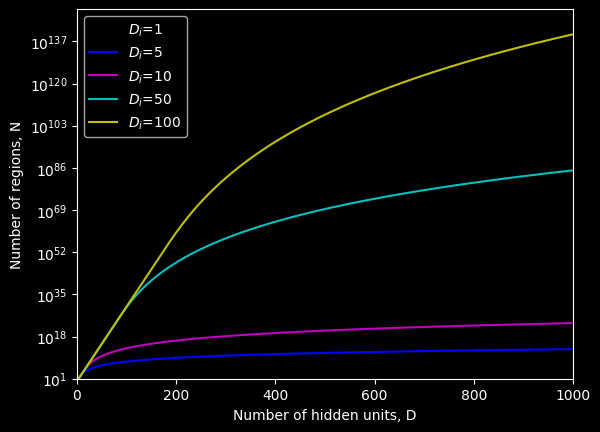

In [16]:
# Now let's plot the graph from figure 3.9a
dims = np.array([1,5,10,50,100])
regions = np.zeros((dims.shape[0], 1000))
for c_dim in range(dims.shape[0]):
    D_i = dims[c_dim]
    print (f"Counting regions for {D_i} input dimensions")
    for D in range(1000):
        regions[c_dim, D] = number_regions(np.min([D_i,D]), D)

fig, ax = plt.subplots()
ax.semilogy(regions[0,:],'k-')
ax.semilogy(regions[1,:],'b-')
ax.semilogy(regions[2,:],'m-')
ax.semilogy(regions[3,:],'c-')
ax.semilogy(regions[4,:],'y-')
ax.legend(['$D_i$=1', '$D_i$=5', '$D_i$=10', '$D_i$=50', '$D_i$=100'])
ax.set_xlabel("Number of hidden units, D")
ax.set_ylabel("Number of regions, N")
plt.xlim([0,1000])
plt.ylim([1e1,1e150])
plt.show()

In [17]:
# Now let's compute and plot the number of regions as a function of the number of parameters as in figure 3.9b
# First let's write a function that computes the number of parameters as a function of the input dimension and number of hidden units (assuming just one output)

def number_parameters(D_i, D):
  N = ((D_i * D) + D) + D + 1
  return N ;

In [19]:
# Now let's test the code
N = number_parameters(10, 8)
print(f"Di=10, D=8, Number of parameters = {int(N)}")

Di=10, D=8, Number of parameters = 97


Counting regions for 1 input dimensions
Counting regions for 5 input dimensions
Counting regions for 10 input dimensions
Counting regions for 50 input dimensions
Counting regions for 100 input dimensions


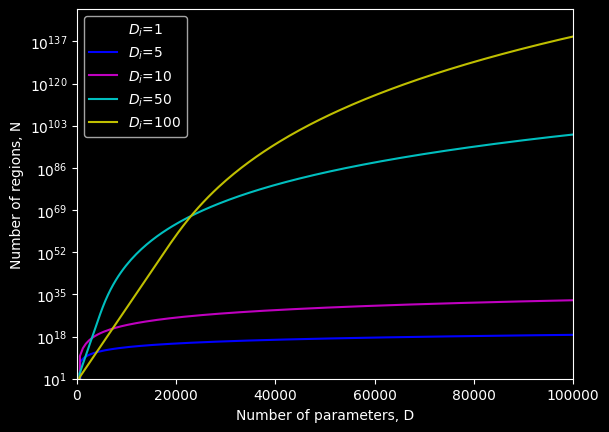

In [20]:
# Now let's plot the graph from figure 3.9b (takes ~1min)
dims = np.array([1,5,10,50,100])
regions = np.zeros((dims.shape[0], 200))
params = np.zeros((dims.shape[0], 200))

# We'll compute the five lines separately this time to make it faster
for c_dim in range(dims.shape[0]):
    D_i = dims[c_dim]
    print (f"Counting regions for {D_i} input dimensions")
    for c_hidden in range(1, 200):
        # Iterate over different ranges of number hidden variables for different input sizes
        D = int(c_hidden * 500 / D_i)
        params[c_dim, c_hidden] =  number_parameters(D_i, D)
        regions[c_dim, c_hidden] = number_regions(np.min([D_i,D]), D)

fig, ax = plt.subplots()
ax.semilogy(params[0,:], regions[0,:],'k-')
ax.semilogy(params[1,:], regions[1,:],'b-')
ax.semilogy(params[2,:], regions[2,:],'m-')
ax.semilogy(params[3,:], regions[3,:],'c-')
ax.semilogy(params[4,:], regions[4,:],'y-')
ax.legend(['$D_i$=1', '$D_i$=5', '$D_i$=10', '$D_i$=50', '$D_i$=100'])
ax.set_xlabel("Number of parameters, D")
ax.set_ylabel("Number of regions, N")
plt.xlim([0,100000])
plt.ylim([1e1,1e150])
plt.show()

#### Why this matters practically

It explains why neural nets don't suffer the classical curse of dimensionality the way grid-based or nearest-neighbor methods do. A method that tries to cover $D_i$-dimensional space with a fixed grid needs exponentially many cells as $D_i$ grows — you pay for the exponential blowup in parameters. A shallow network gets the exponential blowup in regions for free, just by virtue of how hyperplanes intersect in high dimensions.

It's a warning about capacity vs. generalization. Region count is an upper bound on expressivity, not a promise of good behavior — a network with $10^{107}$ potential regions has enormous capacity to overfit if you don't have enough data or regularization. This tension (huge theoretical capacity vs. models that still generalize) is one of the open puzzles in deep learning theory that this result sets up.

It previews why depth matters even more than width. This chapter only analyzes shallow networks. The same style of region-counting analysis (done later for deep networks) shows that stacking layers multiplies this effect further — depth grows regions even faster than adding width does at fixed parameter cost. So this shallow-network result is the simplest case of a much bigger idea: neural networks' efficiency comes from how their pieces compose combinatorially, not just from raw parameter count.


## Universal Approximation theorem 

The Universal Approximation Theorem is one of the foundational ideas behind neural networks. In broad terms, it states that a neural network with at least one sufficiently wide hidden layer can approximate any continuous function on a bounded domain, provided it uses a suitable nonlinear activation function.

Imagine an unknown process that turns inputs into outputs: pixels into an object label, economic indicators into a forecast, or sensor readings into a control signal. If that process can be represented by a continuous function, the theorem tells us that a neural network can, in principle, reproduce it as accurately as we wish—assuming the network has enough hidden units and the right parameters.

What makes this result interesting is its extraordinary generality. Neural networks do not need a separate mathematical architecture for every possible relationship. The same basic building blocks—weighted sums followed by nonlinear transformations—can represent an immense variety of functions. This helps explain why neural networks can be applied across fields as different as computer vision, language processing, medicine, robotics, and scientific modeling.

The theorem also highlights why nonlinearity is essential. A network composed only of linear operations remains a linear function regardless of how many layers it has. Nonlinear activation functions allow simple computational units to combine into intricate curves, boundaries, and patterns.

However, the theorem is an existence result, not a guarantee of practical success. It says that suitable parameters exist, but it does not tell us how to find them, how much data we need, how large the network must be, or whether the model will perform well on unseen examples. A network capable of representing a function may still be difficult to train. It may also memorize its training data instead of learning the underlying pattern.

For this reason, the theorem is best understood as establishing the expressive potential of neural networks—not their automatic intelligence. It assures us that representation is possible, while leaving optimization, efficiency, generalization, and interpretability as the central practical challenges.

That distinction is precisely why the Universal Approximation Theorem remains so compelling. It offers both an ambitious promise and an important warning: neural networks can represent remarkably complex relationships, but possibility alone does not make learning easy.


<img src="assets/Chap03/ShallowApproximate.svg" style="filter: invert(1);" width="100%">

Approximation of a 1D function (dashed line) by a piecewise linear model. a–c) As the number of regions increases, the model becomes closer and
closer to the continuous function. A neural network with a scalar input creates one extra linear region per hidden unit. This idea generalizes to functions in Di dimensions. The universal approximation theorem proves that, with enough hidden units, there exists a shallow neural network that can describe any given
continuous function defined on a compact subset of RDi to arbitrary precision.


\begin{eqnarray}
 h_{d} = \mbox{a}[\theta_{d0} + \theta_{d1}x], 
 \end{eqnarray}


\begin{eqnarray}\label{eq:snn_many_hidden}
 y = \phi_{0}+\sum_{d=1}^{D}\phi_{d}h_{d}.
 \end{eqnarray}